# Experiment 1 — Transformation Recovery

**Goal:** Given paired point clouds $P = T_1(S)$ and $Q = T_2(S)$ (both observed, matching known), fit
$$f(p) = Rp + t + u(p)$$
and check whether it recovers the ground-truth composed transformation $T_2 \circ T_1^{-1}$.
Compare with Rigid Transformation that does not have a residual field:
$$f(p) = Rp + t$$

In [15]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import matplotlib.pyplot as plt

from transformation import RigidTransformation
from elastic_transformation import ElasticTransformation
from synthetic import SyntheticExperiment
from algebra_utils import rotation_angle_error
from visualization import ResidualVisualizer
from tabulate import tabulate
plt.style.use("seaborn-v0_8-whitegrid")

## 1. Synthetic data generation

- $S$: random point cloud (irregular, not a lattice)
- $T_1, T_2$: random rigid transformations with small per-point Gaussian noise
- $P = T_1(S)$, $Q = T_2(S)$  — matching is known ($p_i \leftrightarrow q_i$)
- Because $p_i = T_1(s_i)$ and $q_i = T_2(s_i)$, the ideal map (ignoring noise) is
$$f_{\mathrm{gt}}(p) = T_2 \circ T_1^{-1}(p)$$

In [16]:
exp = SyntheticExperiment.generate(n=2000, noise_std=3.0, t_scale=8.0, seed=42)
print(exp)

╭──────────────────────┬──────────────────────────────────────────────╮
│ Original Point Cloud │ PointCloud(n=2000)                           │
│ Transformation 1     │ RigidTransformation(rot=149.5°, t_norm=5.17) │
│ Transformation 2     │ RigidTransformation(rot=153.1°, t_norm=5.87) │
│ Point Cloud 1        │ PointCloud(n=2000)                           │
│ Point Cloud 2        │ PointCloud(n=2000)                           │
│ GT transformation    │ RigidTransformation(rot=16.3°, t_norm=8.98)  │
╰──────────────────────┴──────────────────────────────────────────────╯


## 2. Baseline: rigid SVD fit

Fit a rigid-only transformation (no residual field) to establish a lower bound on residuals.

In [17]:
# Baseline: rigid-only fit (no residual field)
rigid_fit = RigidTransformation.fit(exp.P, exp.Q)
Q_rigid = rigid_fit.apply(exp.P)
residuals_rigid = np.linalg.norm(Q_rigid.points - exp.Q.points, axis=1)
rigid_rot_err = rotation_angle_error(exp.T_gt.R, rigid_fit.R)
rigid_t_err   = np.linalg.norm(exp.T_gt.t - rigid_fit.t)

## 3. Fit ElasticTransformation

Minimises
$$\min_{R,\,t,\,u}\; \sum_i \|Rp_i + t + u(p_i) - q_i\|^2 + \lambda_1 \sum_i \|u(p_i)\|^2 + \lambda_2 \sum_{i,j} w_{ij}\|u(p_i) - u(p_j)\|^2$$
with Adam, using the 6D rotation representation of Zhou et al. (2019).

In [18]:
f = ElasticTransformation.fit(
    exp.P, exp.Q,
    lambda1=0.1,
    lambda2=0.01,
    n_iter=200,
    lr=1e-2,
    k_neighbors=10,
    verbose=True,
)

ElasticFit: 100%|██████████| 200/200 [00:01<00:00, 122.07it/s, data=50.93412, loss=52.28039, reg=131.37919, u_mag=0.32486]


## 4. Evaluation

In [19]:
rot_err   = rotation_angle_error(exp.T_gt.R, f.R)
t_err     = np.linalg.norm(exp.T_gt.t - f.t)
u_mag     = np.linalg.norm(f.u, axis=1).mean()
Q_pred    = f.apply(exp.P)
residuals = np.linalg.norm(Q_pred.points - exp.Q.points, axis=1)

rows = [
    ["Rotation error",      f"{rigid_rot_err:.4f}°",         f"{rot_err:.4f}°"],
    ["Translation error",   f"{rigid_t_err:.4f}",            f"{t_err:.4f}"],
    ["Mean |u_i|",          "—",                             f"{u_mag:.4f}"],
    ["Mean point residual", f"{residuals_rigid.mean():.4f}", f"{residuals.mean():.4f}"],
    ["Max  point residual", f"{residuals_rigid.max():.4f}",  f"{residuals.max():.4f}"],
]
print(tabulate(rows, headers=["Metric", "Rigid", "Elastic"], tablefmt="rounded_outline"))

╭─────────────────────┬─────────┬───────────╮
│ Metric              │ Rigid   │ Elastic   │
├─────────────────────┼─────────┼───────────┤
│ Rotation error      │ 0.2441° │ 0.2277°   │
│ Translation error   │ 0.3152  │ 0.2835    │
│ Mean |u_i|          │ —       │ 0.4739    │
│ Mean point residual │ 6.7949  │ 6.5859    │
│ Max  point residual │ 19.1136 │ 17.7095   │
╰─────────────────────┴─────────┴───────────╯


## 5. Visualisation

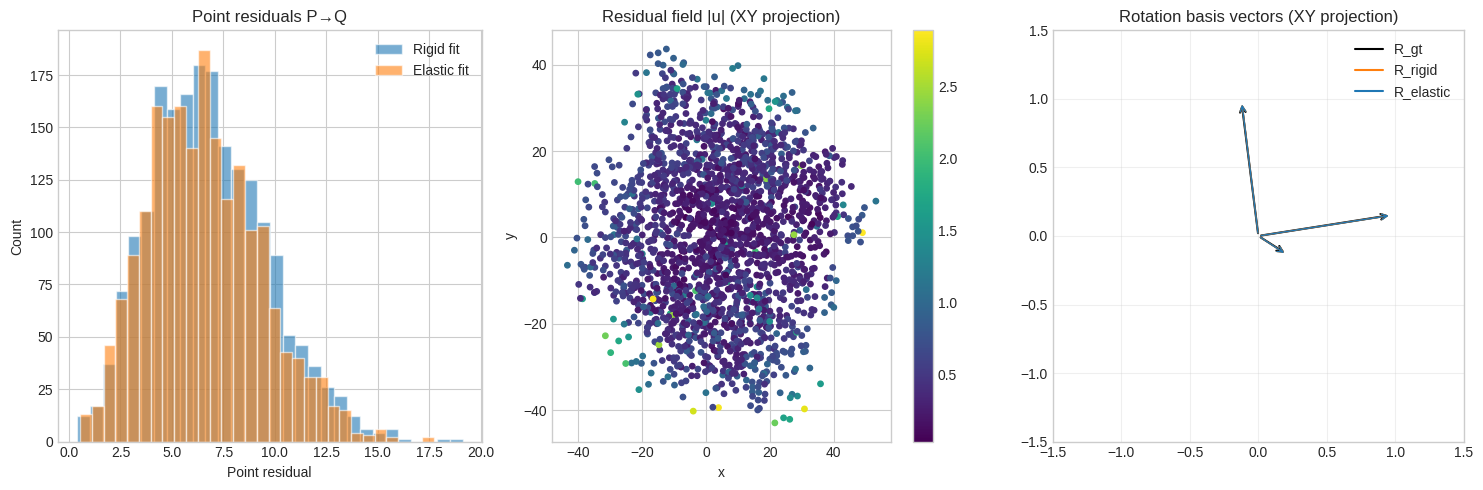

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

u_norms = np.linalg.norm(f.u, axis=1)

ResidualVisualizer.plot_histogram(axes[0], [residuals_rigid, residuals], ['Rigid fit', 'Elastic fit'])
axes[0].set_title('Point residuals P→Q')

ResidualVisualizer.plot_field_heatmap(axes[1], exp.P.points, u_norms)

ResidualVisualizer.plot_rotation_bases(
    axes[2],
    [exp.T_gt.R, rigid_fit.R, f.R],
    ['R_gt', 'R_rigid', 'R_elastic'],
    ['black', 'tab:orange', 'tab:blue'],
)

plt.tight_layout()
plt.savefig('../results/1_rigid_vs_elastic_transformation_results.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Parameter sensitivity sweep

Vary $\lambda_1$ and $\lambda_2$ to see their effect on rotation recovery and residual magnitude.

In [21]:
configs = [
    dict(lambda1=0.0,  lambda2=0.0),
    dict(lambda1=0.1,  lambda2=0.0),
    dict(lambda1=0.0,  lambda2=0.01),
    dict(lambda1=0.1,  lambda2=0.01),
    dict(lambda1=1.0,  lambda2=0.1),
]

rows = []
for cfg in configs:
    fi = ElasticTransformation.fit(
        exp.P, exp.Q, **cfg, n_iter=1000, lr=1e-2, verbose=False
    )
    res = np.linalg.norm(fi.apply(exp.P).points - exp.Q.points, axis=1).mean()
    rows.append({
        'λ1': cfg['lambda1'], 'λ2': cfg['lambda2'],
        'rot_err (°)': round(rotation_angle_error(exp.T_gt.R, fi.R), 3),
        't_err': round(np.linalg.norm(exp.T_gt.t - fi.t), 4),
        'mean|u|': round(np.linalg.norm(fi.u, axis=1).mean(), 4),
        'mean_residual': round(res, 4),
    })

# Print as a table
keys = list(rows[0].keys())
header = '  '.join(f'{k:>14}' for k in keys)
print(header)
print('-' * len(header))
for row in rows:
    print('  '.join(f'{str(v):>14}' for v in row.values()))

            λ1              λ2     rot_err (°)           t_err         mean|u|   mean_residual
----------------------------------------------------------------------------------------------
           0.0             0.0           0.266          0.3458          6.1932          0.6591
           0.1             0.0           0.236          0.3332          5.7498          1.0691
           0.0            0.01           0.304          0.2209          0.5462          6.5642
           0.1            0.01           0.275          0.2988          0.5025          6.5687
           1.0             0.1            0.25          0.3151          0.0957          6.7614
